# Capítulo 3 – Feature Engineering Temporal e Modelos de Machine Learning
**Autor:** Rodrigo Santana Ferreira  
**Disciplina:** Séries Temporais  

---
Este notebook contém os scripts Python apresentados no Capítulo 3, organizados por seção conforme o material da aula.

In [1]:
# Importe as bibliotecas essenciais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

In [2]:
# Utilizando o dataset Airpassengers
from statsmodels.datasets import get_rdataset
air = get_rdataset("AirPassengers").data
air.head(50)

,time,value
0,1949.000000,112
1,1949.083333,118
2,1949.166667,132
3,1949.250000,129
4,1949.333333,121
5,1949.416667,135
6,1949.500000,148
7,1949.583333,148
8,1949.666667,136
9,1949.750000,119


In [3]:
# Define o índice do DataFrame 'air' como um intervalo de datas mensais, começando em janeiro de 1949 e com o mesmo número de períodos que o comprimento de 'air'.
air.index = pd.date_range(start='1949-01', periods=len(air), freq='ME')
air.head(20)

,time,value
1949-01-31,1949.000000,112
1949-02-28,1949.083333,118
1949-03-31,1949.166667,132
1949-04-30,1949.250000,129
1949-05-31,1949.333333,121
1949-06-30,1949.416667,135
1949-07-31,1949.500000,148
1949-08-31,1949.583333,148
1949-09-30,1949.666667,136
1949-10-31,1949.750000,119


In [4]:
# Importa a biblioteca matplotlib.pyplot para criar visualizações e gráficos.
import matplotlib.pyplot as plt
# Importa a função seasonal_decompose do módulo tsa.seasonal do statsmodels para decompor séries temporais em seus componentes.
from statsmodels.tsa.seasonal import seasonal_decompose
# Importa a classe ARIMA do módulo tsa.arima.model do statsmodels para construir e ajustar modelos ARIMA.
from statsmodels.tsa.arima.model import ARIMA
# Importa as funções plot_acf e plot_pacf do módulo graphics.tsaplots do statsmodels para plotar as funções de autocorrelação.
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
# Importa a biblioteca numpy para realizar operações numéricas, como logaritmo.
import numpy as np

In [5]:
# Extrai a coluna 'value' do DataFrame 'air', converte seus valores para o tipo float e armazena-os na variável 'series'.
series = air['value'].astype(float)

In [6]:
# --- Exemplo 1: Decomposição de Série Temporal com seasonal_decompose ---

# Realiza a decomposição de uma série temporal em seus componentes: tendência, sazonalidade e resíduos.
# 'series' é a série temporal original (variável já carregada no notebook).
# 'model='additive'' indica que os componentes são somados (valor = tendência + sazonalidade + resíduo).
# 'period=12' especifica que o padrão sazonal se repete a cada 12 pontos (comum para dados mensais).
decomposition = seasonal_decompose(series, model='additive', period=12)

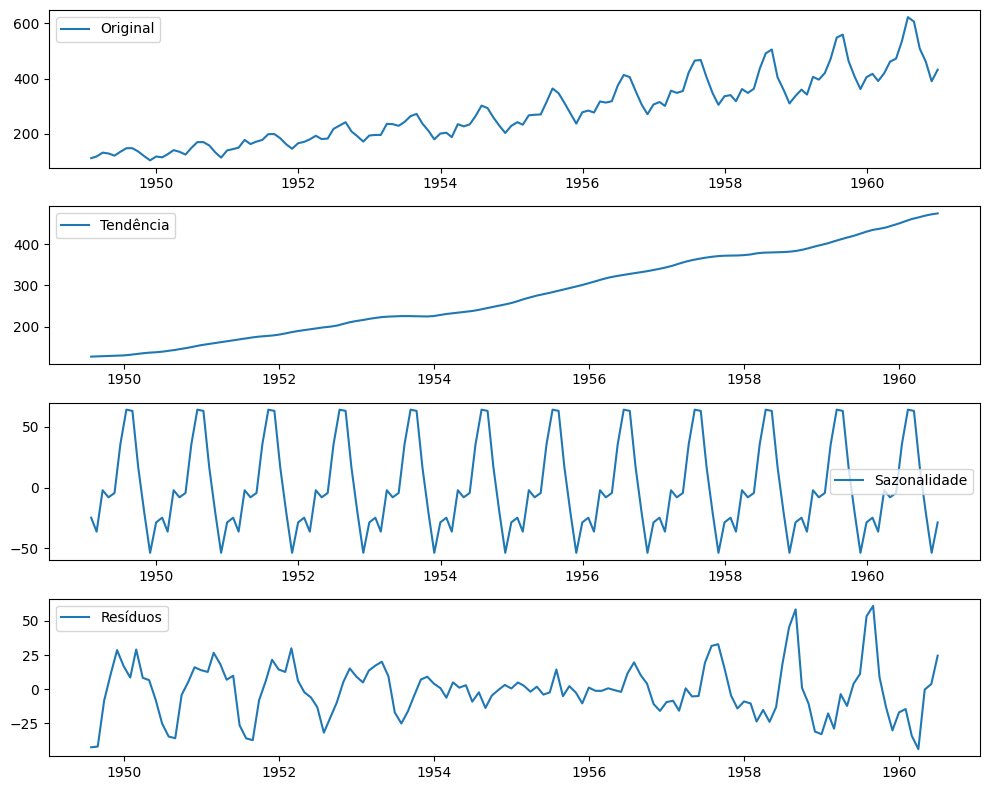

In [7]:
# Cria uma nova figura para os gráficos com um tamanho definido.
plt.figure(figsize=(10, 8))

# Cria um subplot para exibir a série original.
plt.subplot(411) # Configura 4 linhas, 1 coluna, e seleciona a primeira posição.
# Plota a série temporal original.
plt.plot(series, label='Original')
# Adiciona uma legenda ao gráfico.
plt.legend(loc='best')

# Cria um subplot para exibir o componente de tendência.
plt.subplot(412) # Seleciona a segunda posição.
# Plota o componente de tendência extraído da decomposição.
plt.plot(decomposition.trend, label='Tendência')
# Adiciona uma legenda ao gráfico.
plt.legend(loc='best')

# Cria um subplot para exibir o componente sazonal.
plt.subplot(413) # Seleciona a terceira posição.
# Plota o componente sazonal extraído da decomposição.
plt.plot(decomposition.seasonal, label='Sazonalidade')
# Adiciona uma legenda ao gráfico.
plt.legend(loc='best')

# Cria um subplot para exibir o componente de resíduos.
plt.subplot(414) # Seleciona a quarta posição.
# Plota os resíduos (erro) da decomposição, que idealmente devem ser ruído branco.
plt.plot(decomposition.resid, label='Resíduos')
# Adiciona uma legenda ao gráfico.
plt.legend(loc='best')

# Ajusta automaticamente os parâmetros do subplot para que os elementos caibam na figura sem sobreposição.
plt.tight_layout()
# Exibe os gráficos de decomposição.
plt.show()

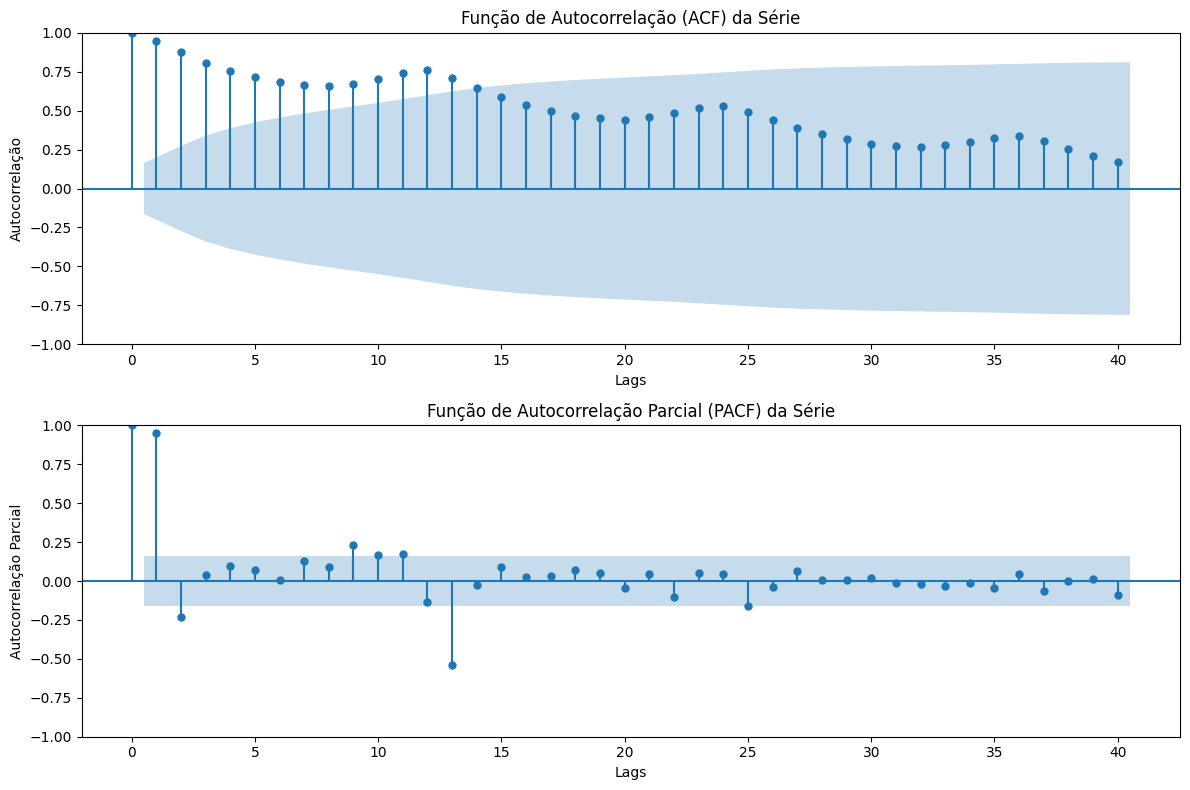

In [8]:
# ────────────────────────────────────────────────
# Plotar gráficos ACF e PACF da série temporal
# ────────────────────────────────────────────────
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Ajustar o tamanho da figura para melhor visualização
plt.figure(figsize=(12, 8))

# Plotar o gráfico ACF
ax1 = plt.subplot(211)
plot_acf(series, ax=ax1, lags=40) # Lags=40 é um bom ponto de partida para dados mensais
plt.title('Função de Autocorrelação (ACF) da Série')
plt.xlabel('Lags')
plt.ylabel('Autocorrelação')

# Plotar o gráfico PACF
ax2 = plt.subplot(212)
plot_pacf(series, ax=ax2, lags=40, method='ywm') # 'ywm' é um método comum para PACF
plt.title('Função de Autocorrelação Parcial (PACF) da Série')
plt.xlabel('Lags')
plt.ylabel('Autocorrelação Parcial')

plt.tight_layout()
plt.show()

# Previsão de séries temporais usando o modelo **ARIMA**

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

In [9]:
# Definir a ordem do modelo ARIMA (p, d, q)
# Para AirPassengers, uma ordem comum para começar é (5,1,0) ou (2,1,1)
# p: número de termos autorregressivos
# d: número de diferenciações para tornar a série estacionária
# q: número de termos de média móvel
arima_order = (5, 1, 0)

In [10]:
print(f"Treinando o modelo ARIMA com ordem: {arima_order}")

# Ajustar o modelo ARIMA aos dados
# Usamos a série 'Passengers' do df_airpassengers
model_arima = ARIMA(series, order=arima_order)
model_fit = model_arima.fit()

Treinando o modelo ARIMA com ordem: (5, 1, 0)


In [11]:
print("Sumário do modelo ARIMA:")
print(model_fit.summary())

Sumário do modelo ARIMA:
                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  144
Model:                 ARIMA(5, 1, 0)   Log Likelihood                -689.067
Date:                Thu, 18 Jun 2026   AIC                           1390.135
Time:                        20:54:09   BIC                           1407.912
Sample:                    01-31-1949   HQIC                          1397.358
                         - 12-31-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3223      0.097      3.334      0.001       0.133       0.512
ar.L2         -0.2170      0.078     -2.776      0.006      -0.370      -0.064
ar.L3         -0.0646      

In [12]:
# Previsões

# Para este exemplo, vamos prever os últimos N valores do dataset para comparação
# Ou prever alguns passos à frente do final do dataset

n_forecast_steps = 24 # Prever os próximos 24 meses após o final dos dados existentes

# Obter o índice do último período nos dados de treinamento
last_date = series.index[-1]

# Criar um novo índice para os períodos de previsão
forecast_index = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=n_forecast_steps, freq='MS')

In [13]:
# mostra exemplos do dataframe forecast_index
forecast_index

DatetimeIndex(['1961-02-01', '1961-03-01', '1961-04-01', '1961-05-01',
               '1961-06-01', '1961-07-01', '1961-08-01', '1961-09-01',
               '1961-10-01', '1961-11-01', '1961-12-01', '1962-01-01',
               '1962-02-01', '1962-03-01', '1962-04-01', '1962-05-01',
               '1962-06-01', '1962-07-01', '1962-08-01', '1962-09-01',
               '1962-10-01', '1962-11-01', '1962-12-01', '1963-01-01'],
              dtype='datetime64[ns]', freq='MS')

In [14]:
# Gerar previsões
# `start` e `end` podem ser índices numéricos ou datas
# Se omitirmos `start` e `end` e usarmos `steps`, ele prevê a partir do final dos dados de treinamento
forecast_result = model_fit.get_forecast(steps=n_forecast_steps)
forecast = forecast_result.predicted_mean
conf_int = forecast_result.conf_int()

In [15]:
# Atribuir o índice correto às previsões
forecast.index = forecast_index
conf_int.index = forecast_index

print("Previsões ARIMA (24 meses):")
print(forecast.head(24))

Previsões ARIMA (24 meses):
1961-02-01    489.459724
1961-03-01    513.421772
1961-04-01    523.538285
1961-05-01    505.021114
1961-06-01    481.184564
1961-07-01    471.972590
1961-08-01    473.299157
1961-09-01    482.408891
1961-10-01    491.484806
1961-11-01    494.185150
1961-12-01    491.917080
1962-01-01    487.640958
1962-02-01    484.411070
1962-03-01    483.958012
1962-04-01    485.455560
1962-05-01    487.317891
1962-06-01    488.368641
1962-07-01    488.245413
1962-08-01    487.450555
1962-09-01    486.698785
1962-10-01    486.405941
1962-11-01    486.584829
1962-12-01    486.961443
1963-01-01    487.241619
Freq: MS, Name: predicted_mean, dtype: float64


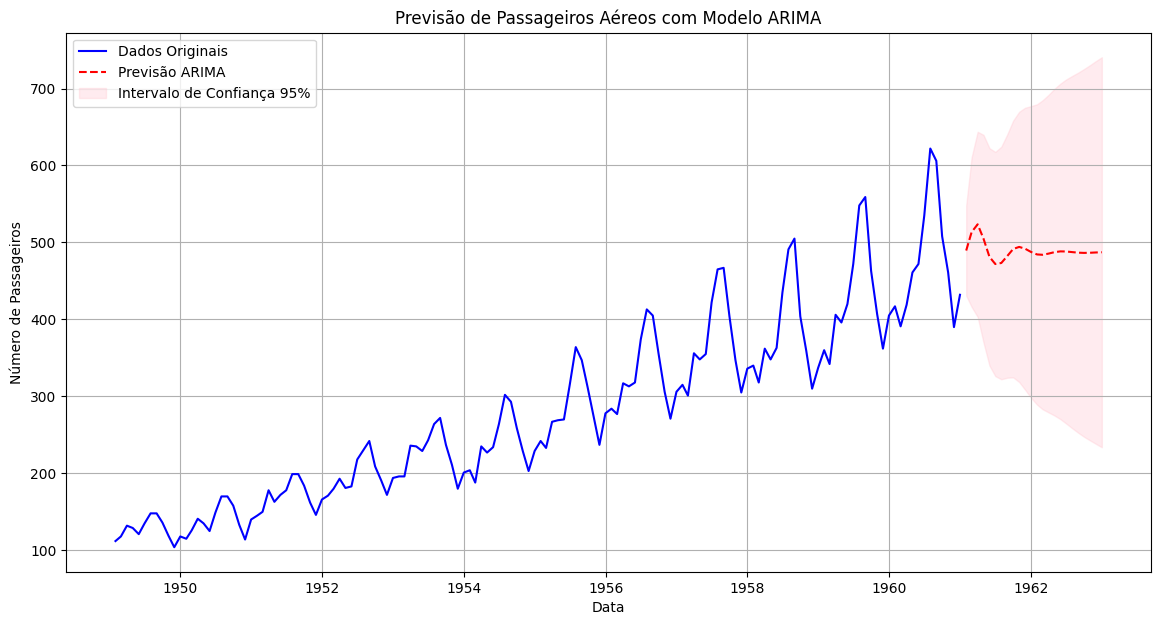

In [16]:
# Visualizar os resultados
plt.figure(figsize=(14, 7))
plt.plot(series, label='Dados Originais', color='blue')
plt.plot(forecast, label='Previsão ARIMA', color='red', linestyle='--')
plt.fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='pink', alpha=0.3, label='Intervalo de Confiança 95%')
plt.title('Previsão de Passageiros Aéreos com Modelo ARIMA')
plt.xlabel('Data')
plt.ylabel('Número de Passageiros')
plt.legend()
plt.grid(True)
plt.show()

# **Previsão de séries temporais usando o modelo SARIMAX**

In [17]:
# ────────────────────────────────────────────────
# Previsão de séries temporais usando o modelo SARIMA
# ────────────────────────────────────────────────
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pandas as pd

In [18]:
# Certifique-se de que df_airpassengers esteja carregado e preparado
# (isso já foi feito nas células anteriores)

# Definir as ordens do modelo SARIMA
# order = (p, d, q)  -> componentes não-sazonais
# seasonal_order = (P, D, Q, S) -> componentes sazonais
# Para AirPassengers, sazonalidade anual S=12 é apropriada.
# Uma ordem comum para começar pode ser (1, 1, 1) para o não-sazonal
# e (1, 1, 1, 12) para o sazonal.
sarima_order = (1, 1, 1)
sarima_seasonal_order = (1, 1, 1, 12)

In [19]:
print(f"Treinando o modelo SARIMA com ordem: {sarima_order} e ordem sazonal: {sarima_seasonal_order}")

Treinando o modelo SARIMA com ordem: (1, 1, 1) e ordem sazonal: (1, 1, 1, 12)


In [20]:
# Ajustar o modelo SARIMA aos dados
# Usamos a série de valores
# enforce_stationarity=False e enforce_invertibility=False podem ajudar
# na convergência para alguns datasets, mas deve ser usado com cautela.
model_sarima = SARIMAX(series,
                       order=sarima_order,
                       seasonal_order=sarima_seasonal_order,
                       enforce_stationarity=True)

In [21]:
model_fit_sarima = model_sarima.fit() # disp=False para não exibir as informações de otimização

In [22]:
print("Sumário do modelo SARIMA:")
print(model_fit_sarima.summary())

Sumário do modelo SARIMA:
                                     SARIMAX Results                                      
Dep. Variable:                              value   No. Observations:                  144
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -506.149
Date:                            Thu, 18 Jun 2026   AIC                           1022.299
Time:                                    20:59:54   BIC                           1036.675
Sample:                                01-31-1949   HQIC                          1028.140
                                     - 12-31-1960                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1272      0.356     -0.358      0.721      -0.825       0.570
ma.L1    

In [23]:
# Fazer previsões
n_forecast_steps = 24 # Prever os próximos 24 meses após o final dos dados existentes

In [24]:
# Obter o índice do último período nos dados de treinamento
last_date = series.index[-1]

In [25]:
# Criar um novo índice para os períodos de previsão
forecast_index = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=n_forecast_steps, freq='MS')

In [26]:
# Gerar previsões
forecast_result_sarima = model_fit_sarima.get_forecast(steps=n_forecast_steps)
forecast_sarima = forecast_result_sarima.predicted_mean
conf_int_sarima = forecast_result_sarima.conf_int()

In [27]:
# Atribuir o índice correto às previsões
forecast_sarima.index = forecast_index
conf_int_sarima.index = forecast_index

print("Previsões SARIMA (primeiros 5 valores):")
print(forecast_sarima.head())

Previsões SARIMA (primeiros 5 valores):
1961-02-01    449.330269
1961-03-01    424.386564
1961-04-01    459.033907
1961-05-01    497.865803
1961-06-01    509.863877
Freq: MS, Name: predicted_mean, dtype: float64


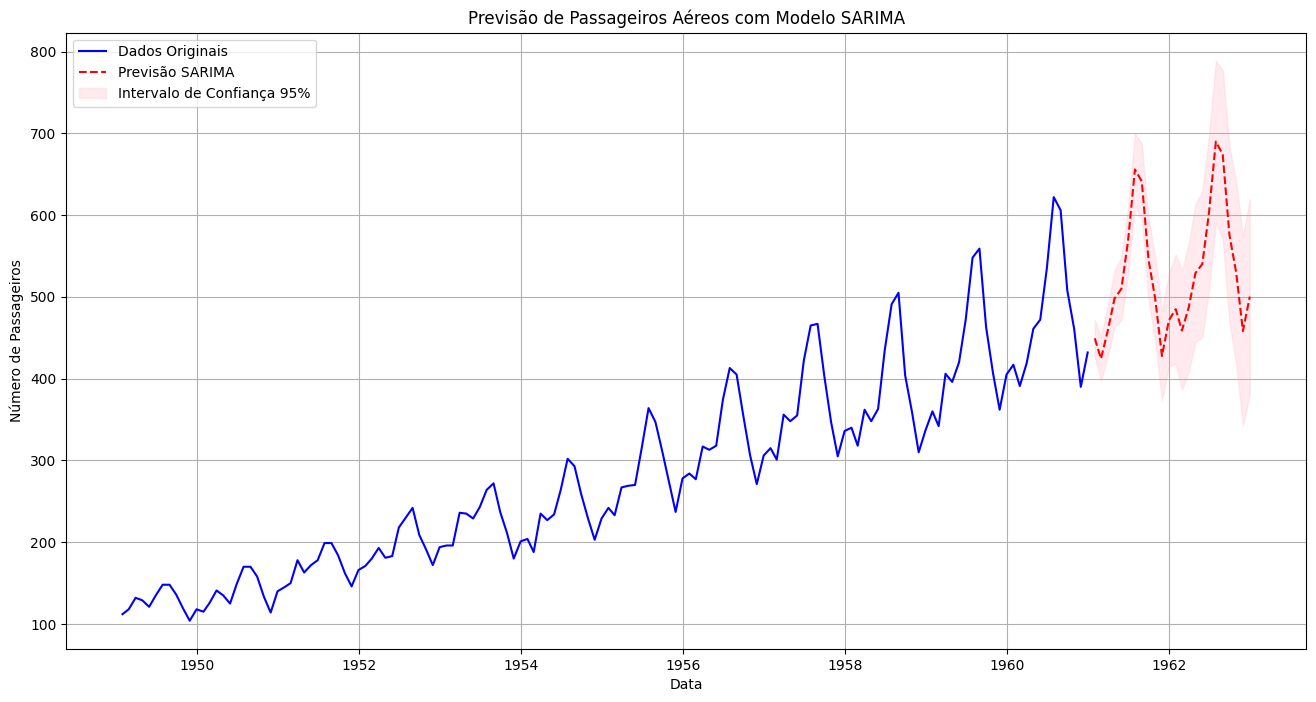

In [28]:
# Visualizar os resultados
plt.figure(figsize=(16, 8))
plt.plot(series, label='Dados Originais', color='blue')
plt.plot(forecast_sarima, label='Previsão SARIMA', color='red', linestyle='--')
plt.fill_between(conf_int_sarima.index, conf_int_sarima.iloc[:, 0], conf_int_sarima.iloc[:, 1], color='pink', alpha=0.3, label='Intervalo de Confiança 95%')
plt.title('Previsão de Passageiros Aéreos com Modelo SARIMA')
plt.xlabel('Data')
plt.ylabel('Número de Passageiros')
plt.legend()
plt.grid(True)
plt.show()

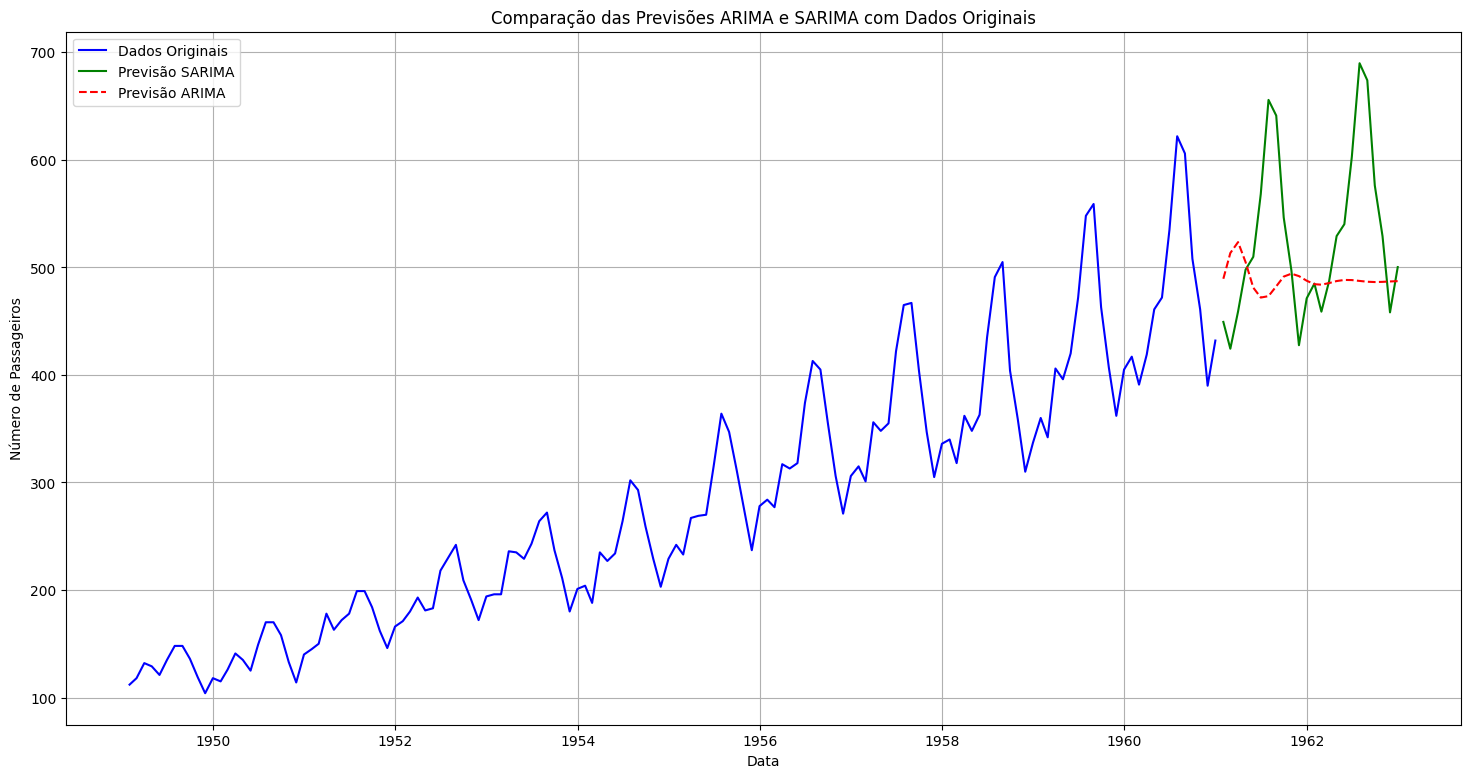

In [29]:
# ────────────────────────────────────────────────
# Plotar e comparar as previsões ARIMA e SARIMA
# ────────────────────────────────────────────────
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 9))
plt.plot(series, label='Dados Originais', color='blue')
plt.plot(forecast_sarima, label='Previsão SARIMA', color='green', linestyle='-')
plt.plot(forecast, label='Previsão ARIMA', color='red', linestyle='--')

plt.title('Comparação das Previsões ARIMA e SARIMA com Dados Originais')
plt.xlabel('Data')
plt.ylabel('Número de Passageiros')
plt.legend()
plt.grid(True)
plt.show()

## 🔧 Instalação de Dependências

In [ ]:
# Instalação das bibliotecas necessárias
!pip install pandas numpy scikit-learn xgboost lightgbm matplotlib statsmodels

## 🏆 Comparação de Modelos de ML para Previsão de Séries Temporais
Comparação de RandomForest, GradientBoosting, XGBoost e LightGBM com validação cruzada temporal usando o dataset AirPassengers (seção HANDS ON).

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
import lightgbm as lgb

In [31]:
# Função para calcular MAPE
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    non_zero = y_true != 0
    return np.mean(np.abs((y_true[non_zero] - y_pred[non_zero]) / y_true[non_zero])) * 100

In [32]:
# Função para calcular MASE (Mean Absolute Scaled Error)
# Usa o erro naïve (previsão = valor do período anterior) como escala
def mean_absolute_scaled_error(y_true, y_pred, y_train):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    naive_errors = np.abs(np.diff(y_train))  # |y_t - y_{t-1}|
    scale = np.mean(naive_errors)
    if scale == 0:
        return np.nan
    return np.mean(np.abs(y_true - y_pred)) / scale

In [33]:
from statsmodels.datasets import get_rdataset
df = get_rdataset("AirPassengers").data
df.head(50)

,time,value
0,1949.000000,112
1,1949.083333,118
2,1949.166667,132
3,1949.250000,129
4,1949.333333,121
5,1949.416667,135
6,1949.500000,148
7,1949.583333,148
8,1949.666667,136
9,1949.750000,119


In [34]:
# Define o índice do DataFrame 'df' como um intervalo de datas mensais, começando em janeiro de 1949 e com o mesmo número de períodos que o comprimento de 'df'.
df.index = pd.date_range(start='1949-01', periods=len(df), freq='ME')
df.head(5)

,time,value
1949-01-31,1949.000000,112
1949-02-28,1949.083333,118
1949-03-31,1949.166667,132
1949-04-30,1949.250000,129
1949-05-31,1949.333333,121


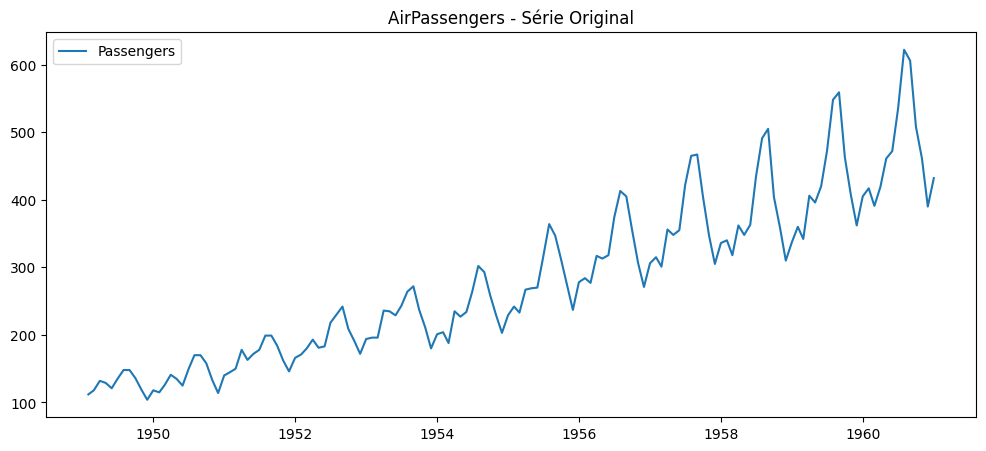

In [35]:
# Plot da série original
plt.figure(figsize=(12, 5))
plt.plot(df['value'], label='Passengers')
plt.title('AirPassengers - Série Original')
plt.legend()
plt.show()

In [36]:
# ────────────────────────────────────────────────
# 2. Feature Engineering Temporal (básico + cíclico)
# ────────────────────────────────────────────────
df['lag_1']   = df['value'].shift(1)
df['lag_12']  = df['value'].shift(12)  # sazonalidade anual
df['diff_1']  = df['value'].diff(1)
df['rolling_mean_3']  = df['value'].rolling(3).mean()
df['rolling_mean_12'] = df['value'].rolling(12).mean()

In [37]:
# Features cíclicas (mês do ano)
df['month'] = df.index.month
df['sin_month'] = np.sin(2 * np.pi * df['month'] / 12)
df['cos_month'] = np.cos(2 * np.pi * df['month'] / 12)

In [38]:
# Remover NaNs gerados pelos shifts e rolling
df = df.dropna().copy()

In [39]:
df.head()

,time,value,lag_1,lag_12,diff_1,rolling_mean_3,rolling_mean_12,month,sin_month,cos_month
1950-01-31,1950.000000,115,118.0,112.0,-3.0,112.333333,126.916667,1,0.500000,8.660254e-01
1950-02-28,1950.083333,126,115.0,118.0,11.0,119.666667,127.583333,2,0.866025,5.000000e-01
1950-03-31,1950.166667,141,126.0,132.0,15.0,127.333333,128.333333,3,1.000000,6.123234e-17
1950-04-30,1950.250000,135,141.0,129.0,-6.0,134.000000,128.833333,4,0.866025,-5.000000e-01
1950-05-31,1950.333333,125,135.0,121.0,-10.0,133.666667,129.166667,5,0.500000,-8.660254e-01


In [40]:
# Definir X e y
X = df.drop('value', axis=1)
y = df['value']

In [41]:
print("Features criadas:", X.columns.tolist())
print("Shape final X/y:", X.shape, y.shape)

Features criadas: ['time', 'lag_1', 'lag_12', 'diff_1', 'rolling_mean_3', 'rolling_mean_12', 'month', 'sin_month', 'cos_month']
Shape final X/y: (132, 9) (132,)


In [42]:
# ────────────────────────────────────────────────
# 3. Definir modelos a comparar
# ────────────────────────────────────────────────
models = {
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost': xgb.XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'LightGBM': lgb.LGBMRegressor(n_estimators=100, random_state=42, verbose=-1)
}

In [43]:
# ────────────────────────────────────────────────
# 4. Validação cruzada temporal + cálculo de métricas
# ────────────────────────────────────────────────
tscv = TimeSeriesSplit(n_splits=5)  # 5 folds temporais
results = []

for name, model in models.items():
    mae_list, rmse_list, mape_list, mase_list = [], [], [], []

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X), 1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        mae  = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mape = mean_absolute_percentage_error(y_test, y_pred)
        mase = mean_absolute_scaled_error(y_test, y_pred, y_train)

        mae_list.append(mae)
        rmse_list.append(rmse)
        mape_list.append(mape)
        mase_list.append(mase)

        print(f"Fold {fold} - {name}: MAE={mae:.2f}, RMSE={rmse:.2f}, MAPE={mape:.2f}%, MASE={mase:.3f}")

Fold 1 - RandomForest: MAE=22.35, RMSE=31.68, MAPE=9.61%, MASE=1.591
Fold 2 - RandomForest: MAE=20.85, RMSE=24.94, MAPE=9.04%, MASE=1.458
Fold 3 - RandomForest: MAE=36.02, RMSE=48.58, MAPE=10.21%, MASE=2.117
Fold 4 - RandomForest: MAE=33.84, RMSE=42.82, MAPE=8.47%, MASE=1.689
Fold 5 - RandomForest: MAE=35.22, RMSE=48.77, MAPE=7.08%, MASE=1.500
Fold 1 - GradientBoosting: MAE=23.19, RMSE=32.07, MAPE=10.12%, MASE=1.651
Fold 2 - GradientBoosting: MAE=20.71, RMSE=25.18, MAPE=9.08%, MASE=1.448
Fold 3 - GradientBoosting: MAE=33.76, RMSE=45.69, MAPE=9.59%, MASE=1.984
Fold 4 - GradientBoosting: MAE=34.78, RMSE=44.81, MAPE=8.61%, MASE=1.736
Fold 5 - GradientBoosting: MAE=36.61, RMSE=49.54, MAPE=7.31%, MASE=1.560
Fold 1 - XGBoost: MAE=21.41, RMSE=30.06, MAPE=9.24%, MASE=1.524
Fold 2 - XGBoost: MAE=31.96, RMSE=37.91, MAPE=14.49%, MASE=2.235
Fold 3 - XGBoost: MAE=28.83, RMSE=42.31, MAPE=8.03%, MASE=1.695
Fold 4 - XGBoost: MAE=29.19, RMSE=40.45, MAPE=7.09%, MASE=1.457
Fold 5 - XGBoost: MAE=51.64, RM

In [44]:
    # Médias do modelo
    results.append({
        'Modelo': name,
        'MAE_mean': np.mean(mae_list),
        'RMSE_mean': np.mean(rmse_list),
        'MAPE_mean': np.mean(mape_list),
        'MASE_mean': np.mean(mase_list)
    })

In [45]:
# ────────────────────────────────────────────────
# 5. Resultados finais (tabela comparativa)
# ────────────────────────────────────────────────
results_df = pd.DataFrame(results).round(3)
print("\nComparação Final (médias dos 5 folds):")
print(results_df.sort_values('MASE_mean'))  # MASE é uma boa métrica escalada para séries temporais


Comparação Final (médias dos 5 folds):
     Modelo  MAE_mean  RMSE_mean  MAPE_mean  MASE_mean
0  LightGBM    53.654     65.406     16.244       3.06


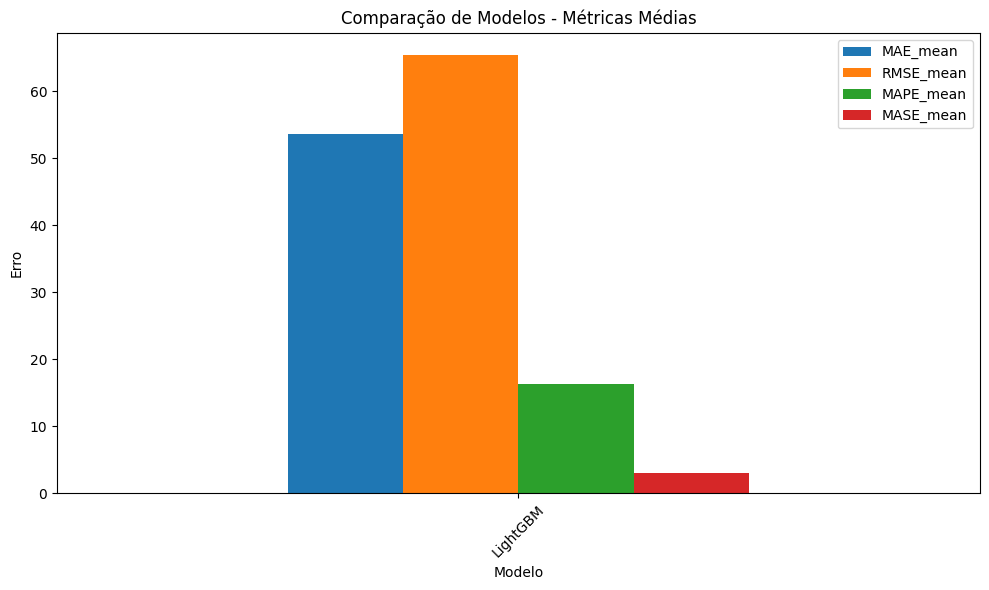

In [46]:
# Visualização rápida
results_df.set_index('Modelo')[['MAE_mean', 'RMSE_mean', 'MAPE_mean', 'MASE_mean']].plot(kind='bar', figsize=(10,6))
plt.title('Comparação de Modelos - Métricas Médias')
plt.ylabel('Erro')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()